# Exchange Rate Forecasting — Data Preparation and Exploratory Analysis

This notebook prepares the daily exchange-rate and macroeconomic data used in the project, converts the series to monthly frequency, creates the unified modeling dataset, and performs the exploratory time-series analysis used to guide model selection.

## 1. Load the raw datasets

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")

eurusd = pd.read_csv(DATA_DIR / "EURUSD.csv")
usdjpy = pd.read_csv(DATA_DIR / "USDJPY.csv")
usdinr = pd.read_csv(DATA_DIR / "USDINR.csv")
gbpusd = pd.read_csv(DATA_DIR / "GBPUSD.csv")
audusd = pd.read_csv(DATA_DIR / "AUDUSD.csv")
dxy = pd.read_csv(DATA_DIR / "DXY.csv")

brent = pd.read_csv(DATA_DIR / "DCOILBRENTEU.csv")
fedfunds = pd.read_csv(DATA_DIR / "FEDFUNDS.csv")
cpi = pd.read_csv(DATA_DIR / "CPIAUCSL.csv")
trade_balance = pd.read_csv(DATA_DIR / "BOPGSTB.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 2. Clean and standardize the source data

In [2]:
def clean_yfinance_data(df, new_column_name):
    df = df.iloc[2:].copy()
    df = df[['Price', 'Close']]
    df.columns = ['Date', new_column_name]
    df['Date'] = pd.to_datetime(df['Date'])
    df[new_column_name] = pd.to_numeric(df[new_column_name], errors='coerce')
    return df

eurusd = clean_yfinance_data(eurusd, "EURUSD")
usdjpy = clean_yfinance_data(usdjpy, "USDJPY")
usdinr = clean_yfinance_data(usdinr, "USDINR")
gbpusd = clean_yfinance_data(gbpusd, "GBPUSD")
audusd = clean_yfinance_data(audusd, "AUDUSD")
dxy = clean_yfinance_data(dxy, "DXY")

def clean_fred_data(df, value_column):
    df = df.copy()
    df.columns = ['Date', value_column]
    df['Date'] = pd.to_datetime(df['Date'])
    df[value_column] = pd.to_numeric(df[value_column], errors='coerce')
    return df

brent = clean_fred_data(brent, "Brent_Oil")
fedfunds = clean_fred_data(fedfunds, "Fed_Funds")
cpi = clean_fred_data(cpi, "CPI")
trade_balance = clean_fred_data(trade_balance, "Trade_Balance")

print("All source datasets cleaned successfully.")

All source datasets cleaned successfully.


## 3. Convert to monthly frequency and align macroeconomic data

In [3]:
def convert_to_monthly(df, value_column):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df = df.resample('ME').mean()
    return df.reset_index()

def align_month_end(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Date'] = df['Date'] + pd.offsets.MonthEnd(0)
    return df

eurusd_monthly = convert_to_monthly(eurusd, "EURUSD")
usdjpy_monthly = convert_to_monthly(usdjpy, "USDJPY")
usdinr_monthly = convert_to_monthly(usdinr, "USDINR")
gbpusd_monthly = convert_to_monthly(gbpusd, "GBPUSD")
audusd_monthly = convert_to_monthly(audusd, "AUDUSD")
dxy_monthly = convert_to_monthly(dxy, "DXY")

brent = align_month_end(brent)
fedfunds = align_month_end(fedfunds)
cpi = align_month_end(cpi)
trade_balance = align_month_end(trade_balance)
brent_monthly = convert_to_monthly(brent, "Brent_Oil")

print("Monthly conversion and date alignment completed.")

Monthly conversion and date alignment completed.


## 4. Build the final monthly dataset

In [4]:
master_monthly = eurusd_monthly.copy()

for df in [usdjpy_monthly, usdinr_monthly, gbpusd_monthly, audusd_monthly, dxy_monthly]:
    master_monthly = master_monthly.merge(df, on="Date", how="left")

master_monthly = master_monthly.merge(brent_monthly, on="Date", how="left")
master_monthly = master_monthly.merge(fedfunds, on="Date", how="left")
master_monthly = master_monthly.merge(cpi, on="Date", how="left")
master_monthly = master_monthly.merge(trade_balance, on="Date", how="left")

print("Final monthly master dataset:")
print(master_monthly.head())
print("Shape:", master_monthly.shape)

print("\nMissing values before filling:")
print(master_monthly.isna().sum())

master_monthly = master_monthly.ffill()

print("\nMissing values after forward filling:")
print(master_monthly.isna().sum())

master_monthly.to_csv(DATA_DIR / "processed_monthly_exchange_data.csv", index=False)
print("\nSaved processed dataset to data/processed_monthly_exchange_data.csv")

Final monthly master dataset:
        Date    EURUSD     USDJPY  ...  Fed_Funds      CPI  Trade_Balance
0 2010-01-31  1.427858  91.208095  ...       0.11  217.488         -37744
1 2010-02-28  1.368163  90.203100  ...       0.13  217.281         -41504
2 2010-03-31  1.357616  90.711131  ...       0.16  217.353         -40271
3 2010-04-30  1.342915  93.461091  ...       0.20  217.403         -41496
4 2010-05-31  1.252892  91.839477  ...       0.20  217.290         -42088

[5 rows x 11 columns]
Shape: (192, 11)

Missing values before filling:
Date             0
EURUSD           0
USDJPY           0
USDINR           0
GBPUSD           0
AUDUSD           0
DXY              0
Brent_Oil        0
Fed_Funds        0
CPI              1
Trade_Balance    0
dtype: int64

Missing values after forward filling:
Date             0
EURUSD           0
USDJPY           0
USDINR           0
GBPUSD           0
AUDUSD           0
DXY              0
Brent_Oil        0
Fed_Funds        0
CPI              0
Tra

## 5. Exchange-rate trends and correlations

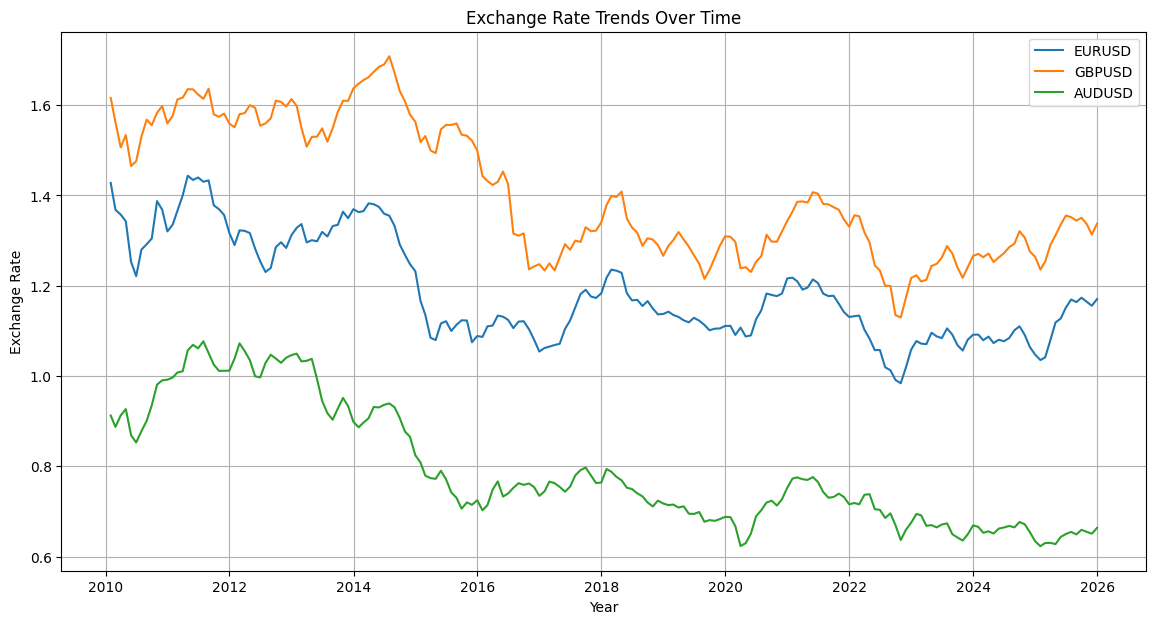

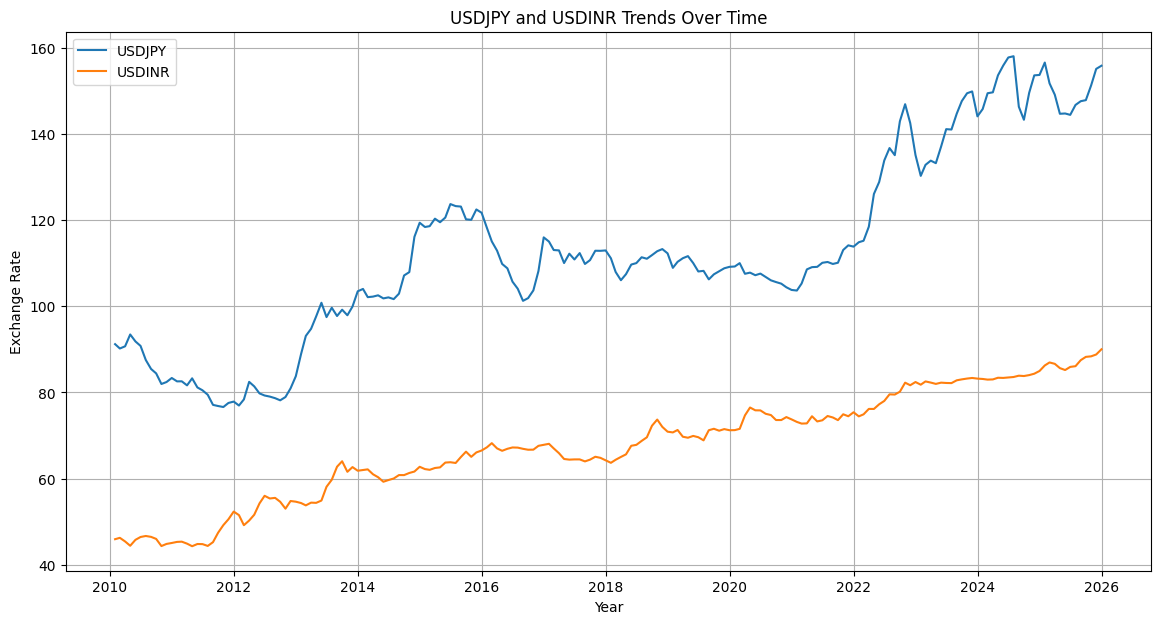

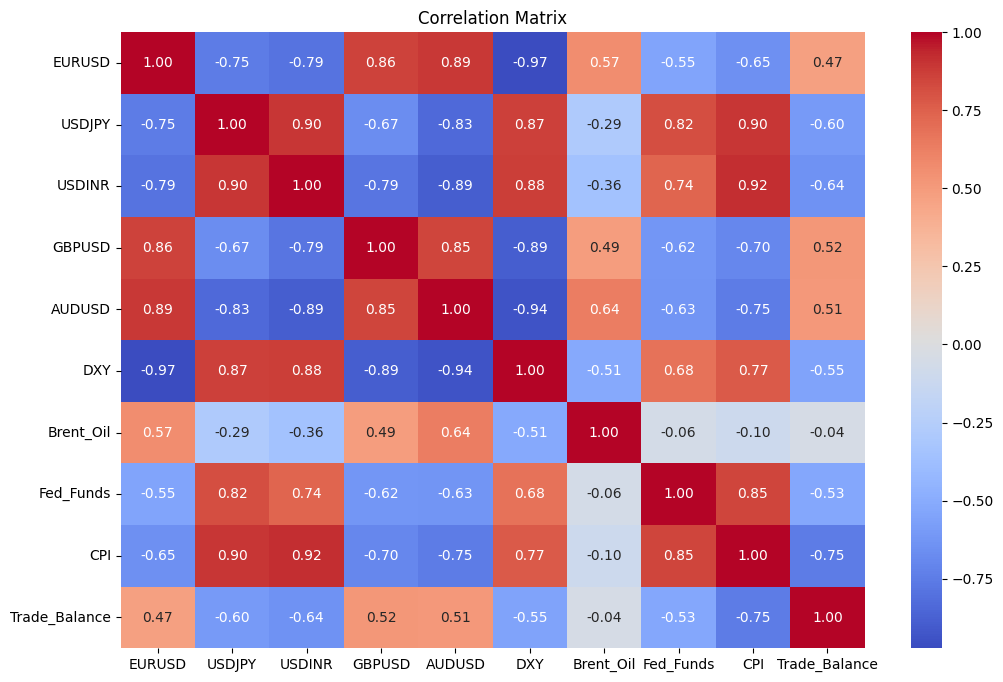

In [5]:
plt.figure(figsize=(14, 7))
for col in ["EURUSD", "GBPUSD", "AUDUSD"]:
    plt.plot(master_monthly["Date"], master_monthly[col], label=col)
plt.title("Exchange Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))
for col in ["USDJPY", "USDINR"]:
    plt.plot(master_monthly["Date"], master_monthly[col], label=col)
plt.title("USDJPY and USDINR Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

correlation_matrix = master_monthly.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 6. Stationarity and autocorrelation analysis

ADF Test for EURUSD
ADF Statistic: -1.790532052308676
p-value: 0.3851722949028093
Critical Values:
1%: -3.465811691080702
5%: -2.877123351472649
10%: -2.5750770662586864

ADF Test for Differenced EURUSD
ADF Statistic: -10.498791572285139
p-value: 1.0977108051687658e-18
Critical Values:
1%: -3.4652439354133255
5%: -2.8768752281673717
10%: -2.574944653739612


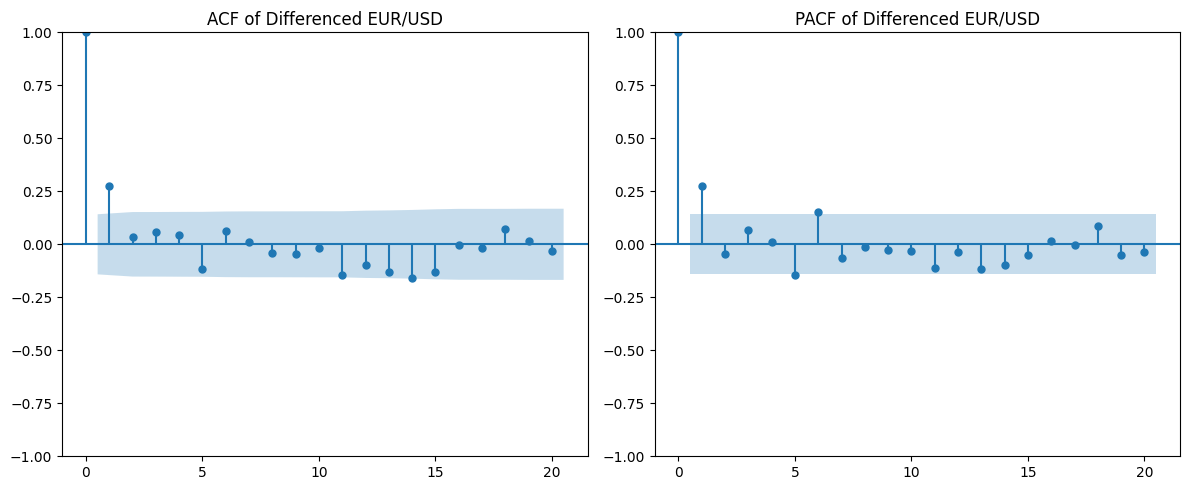

In [6]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

result = adfuller(master_monthly["EURUSD"])
print("ADF Test for EURUSD")
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

master_monthly["EURUSD_diff"] = master_monthly["EURUSD"].diff()
result_diff = adfuller(master_monthly["EURUSD_diff"].dropna())

print("\nADF Test for Differenced EURUSD")
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(master_monthly["EURUSD_diff"].dropna(), ax=axes[0], lags=20)
axes[0].set_title("ACF of Differenced EUR/USD")
plot_pacf(master_monthly["EURUSD_diff"].dropna(), ax=axes[1], lags=20)
axes[1].set_title("PACF of Differenced EUR/USD")
plt.tight_layout()
plt.show()

## 7. Log returns

       EURUSD_logret  USDJPY_logret  ...  GBPUSD_logret  AUDUSD_logret
count     191.000000     191.000000  ...     191.000000     191.000000
mean       -0.001040       0.002805  ...      -0.000991      -0.001668
std         0.019012       0.021962  ...       0.018998       0.022154
min        -0.069388      -0.077081  ...      -0.079732      -0.068600
25%        -0.011636      -0.010261  ...      -0.011789      -0.015379
50%        -0.001614       0.001847  ...      -0.000102      -0.000953
75%         0.009284       0.015256  ...       0.013824       0.013635
max         0.061538       0.073084  ...       0.037347       0.056993

[8 rows x 5 columns]


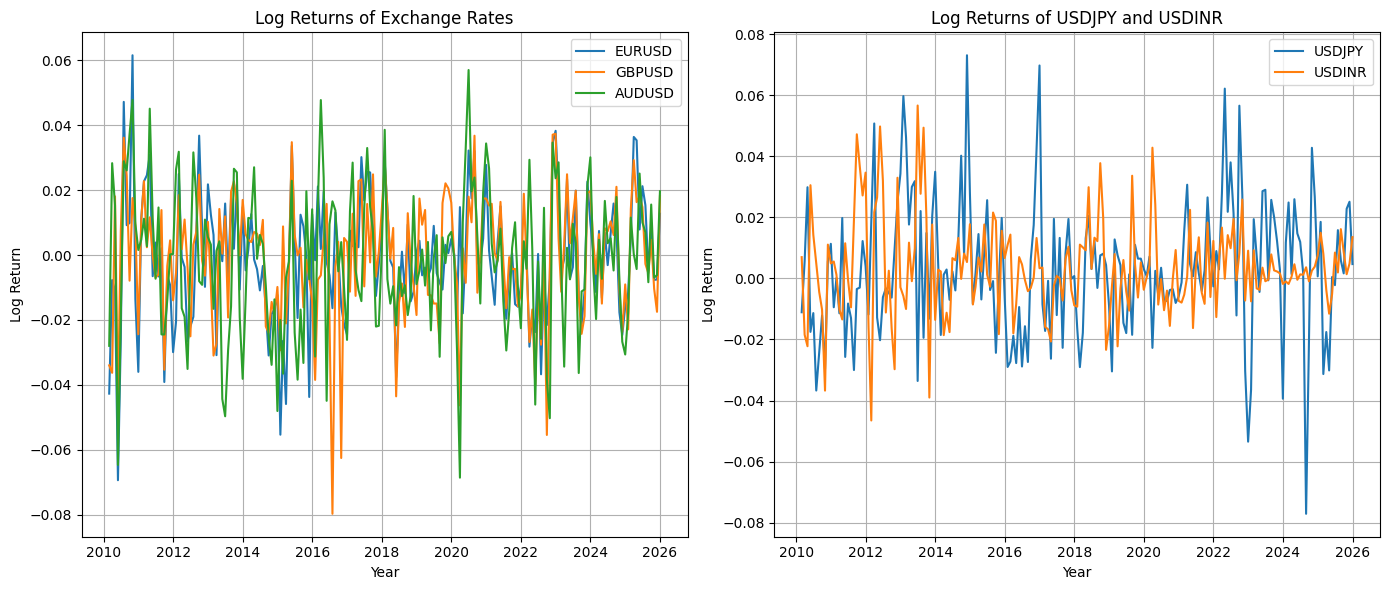

In [7]:
exchange_cols = ["EURUSD", "USDJPY", "USDINR", "GBPUSD", "AUDUSD"]

for col in exchange_cols:
    master_monthly[f"{col}_logret"] = np.log(
        master_monthly[col] / master_monthly[col].shift(1)
    )

log_returns = master_monthly[[f"{col}_logret" for col in exchange_cols]].dropna()

print(log_returns.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for col in ["EURUSD", "GBPUSD", "AUDUSD"]:
    axes[0].plot(master_monthly["Date"], master_monthly[f"{col}_logret"], label=col)
axes[0].set_title("Log Returns of Exchange Rates")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Log Return")
axes[0].legend()
axes[0].grid(True)

for col in ["USDJPY", "USDINR"]:
    axes[1].plot(master_monthly["Date"], master_monthly[f"{col}_logret"], label=col)
axes[1].set_title("Log Returns of USDJPY and USDINR")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Log Return")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()